In [175]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from scipy.stats import norm

from src.data_generators import generate_var3_3d,true_var3_3d_conditional_density
from src.r_bp import fit_R_BP_marginals_until_t
from src.transform import X_to_U
from src.lag import lagged_k_U
from src.copula import fit_conditional_vines,conditional_vine_copula_cdf, estimate_gaussian_clayton_gas, compute_time_varying_copula_paths, gaussian_copula_log_density, clayton_copula_log_density, fit_gaussian_clayton_mixture
from src.conditional_density import  build_u_tilde_data, conditional_marginal_all
from src.predictive_density import predictive_density
from src.R_BP_james import fit_R_BP_marginals, fit_R_BP_marginals_observed
from src.metropolis_hastings import metropolis_hastings, mvn_def, sample_mvn

In [165]:
import importlib
import src.R_BP_james
import src.copula

importlib.reload(src.R_BP_james)
importlib.reload(src.copula)

<module 'src.copula' from '/Users/chaeyunkim/Desktop/time varying copula /src/copula.py'>

In [34]:
# ============================================================
# 1. VAR(3) 데이터 생성
# ============================================================

X, A1, A2, A3, Sigma = generate_var3_3d(T=1000, burn_in=300)

print("X shape:", X.shape)

X shape: (1000, 3)


In [35]:
# ============================================================
# 2. 학습 데이터와 다음 관측값 분리
# ============================================================

t = 800

# 시점 t까지 관측된 데이터
X_train = X[:t]

# density를 계산할 실제 다음 관측값 X_{t+1}
X_target = X[t:t+1]
y = X_target[0]

print("X_train shape:", X_train.shape)
print("X_target shape:", X_target.shape)
print("y:", y)

X_train shape: (800, 3)
X_target shape: (1, 3)
y: [3.81089663 2.78414067 4.21690918]


In [90]:
# ============================================================
# 3-1. 각 변수의 R-BP marginal PDF와 CDF 추정 - 내 코드
# ============================================================

rho_grid = np.linspace(0.01, 0.99, 50)

(x_grids_t,
 p0_grids_t,
 P0_grids_t,
 rho_hats_t,
 p_grids_t,
 P_grids_t) = fit_R_BP_marginals_until_t( X_train=X_train,
                                          rho_grid=rho_grid)

print("Estimated R-BP rho:")
print(rho_hats_t)

# ============================================================
# 4. X 데이터를 uniform 데이터 U로 변환
# ============================================================

U_train_t = X_to_U( X=X_train,
                    x_grids=x_grids_t,
                    P_grids=P_grids_t )

print("U_train_t shape:", U_train_t.shape)
print("U range:", U_train_t.min(), U_train_t.max())

Estimated R-BP rho:
[np.float64(0.13), np.float64(0.93), np.float64(0.01)]
U_train_t shape: (800, 3)
U range: 0.00027552180320283685 0.9995918357956601


In [101]:
# ============================================================
# 3-2. 각 변수의 R-BP marginal PDF와 CDF 추정 및 U 변환- james
# ============================================================


(x_grids,
 p0_grids,
 P0_grids,
 rhos,
 p_grids,
 P_grids,
 Us) = fit_R_BP_marginals_observed(X_train=X_train, n_grid=1000)

print("Estimated R-BP rho:")
print(rhos)

Estimated R-BP rho:
[0.8024228  0.67580436 0.87013375]


In [102]:
print(Us.shape)

(800, 3)


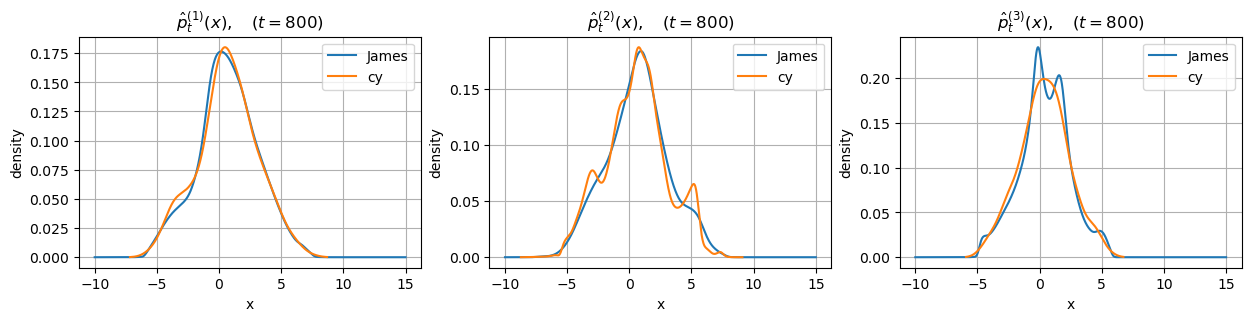

In [103]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3))

for j in range(3):
    axes[j].plot(x_grids[j], p_grids[j],label="James") # james
    axes[j].plot(x_grids_t[j], p_grids_t[j],label="cy") #cy
    axes[j].set_title(rf"$\hat p_{{t}}^{{({j+1})}}(x),\quad (t=800)$")
    axes[j].set_xlabel("x")
    axes[j].set_ylabel("density")
    axes[j].grid(True)
    axes[j].legend()



plt.show()

여기서 부터는 james 코드로 만든 R-BP 사용해서 나온 값 사용했음 


-
-
-
-
-
-
-
-
-
-
-
-
-
-










In [104]:
# ============================================================
# 5. VAR(3)에 맞게 3개 lag 조건변수 생성
# ============================================================

k = 3

U_condition_train, U_target_train = lagged_k_U(
    U=Us,
    k=k
)

print("U_condition_train shape:", U_condition_train.shape)
print("U_target_train shape:", U_target_train.shape)


# 다음 시점 예측에 사용할 최근 3개 lag
#
# 순서:
# [U1_(t-2), U1_(t-1), U1_t,
#  U2_(t-2), U2_(t-1), U2_t,
#  U3_(t-2), U3_(t-1), U3_t]

u_condition_pred = Us[-k:, :].T.reshape(-1)

print("u_condition_pred:")
print(u_condition_pred)


U_condition_train shape: (797, 9)
U_target_train shape: (797, 3)
u_condition_pred:
[0.88781754 0.84703241 0.95733618 0.9510278  0.92458089 0.94464387
 0.93246112 0.92905143 0.95359512]


In [105]:
# ============================================================
# 6. 각 변수의 conditional vine copula 추정
# ============================================================

vines_t = fit_conditional_vines(
    U_condition=U_condition_train,
    U_target=U_target_train
)

print("Number of fitted vines:", len(vines_t))

Number of fitted vines: 3


In [144]:
vines_t

[<pyvinecopulib.Vinecop> Vinecop model with 10 variables
 tree edge conditioned variables  conditioning variables var_types       family rotation  parameters  df  tau 
    1    1                  5, 2                              c, c     Gaussian        0        0.83 1.0 0.62 
    1    2                  2, 3                              c, c     Gaussian        0        0.85 1.0 0.65 
    1    3                  1, 4                              c, c     Gaussian        0        0.85 1.0 0.65 
    1    4                  7, 4                              c, c     Gaussian        0        0.83 1.0 0.62 
    1    5                  6, 3                              c, c     Gaussian        0        0.83 1.0 0.62 
    1    6                  3, 4                              c, c     Gaussian        0        0.85 1.0 0.65 
    1    7                  8, 9                              c, c      Student        0 0.82, 10.94 2.0 0.61 
    1    8                 4, 10                       

In [204]:
vines_t[0]

<pyvinecopulib.Vinecop> Vinecop model with 10 variables
tree edge conditioned variables  conditioning variables var_types       family rotation  parameters  df  tau 
   1    1                  5, 2                              c, c     Gaussian        0        0.83 1.0 0.62 
   1    2                  2, 3                              c, c     Gaussian        0        0.85 1.0 0.65 
   1    3                  1, 4                              c, c     Gaussian        0        0.85 1.0 0.65 
   1    4                  7, 4                              c, c     Gaussian        0        0.83 1.0 0.62 
   1    5                  6, 3                              c, c     Gaussian        0        0.83 1.0 0.62 
   1    6                  3, 4                              c, c     Gaussian        0        0.85 1.0 0.65 
   1    7                  8, 9                              c, c      Student        0 0.82, 10.94 2.0 0.61 
   1    8                 4, 10                              c, 

True conditional mean:
[4.26095279 4.38489647 3.56465529]


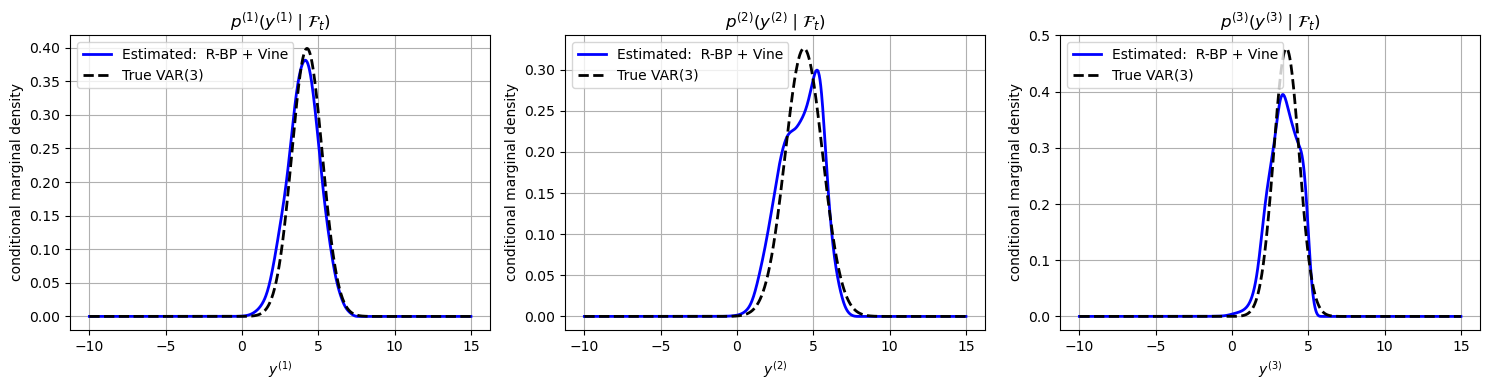

In [205]:
# ============================================================
# t=800의 conditional marginal PDF 곡선
# R-BP +  vine
# ============================================================

eps = 1e-6
s_grid = np.linspace(eps, 1 - eps, 300)

p_cond_curves = []

for j in range(3):

    # James R-BP의 marginal CDF grid
    u_grid = np.clip(P_grids[j], eps, 1 - eps,)

    # t=800에서 고정된 최근 lag 조건
    u_cond = np.clip( u_condition_pred, eps, 1 - eps)

    # Vine conditional density의 분자
    numerator_inputs = np.column_stack([ u_grid, np.tile(u_cond, (len(u_grid), 1))])
    numerator = vines_t[j].pdf(numerator_inputs)

    # Vine conditional density의 분모
    denominator_inputs = np.column_stack([ s_grid, np.tile(u_cond, (len(s_grid), 1)),])
    denominator = np.trapezoid( vines_t[j].pdf(denominator_inputs), s_grid)

    # --------------------------------------------------------
    # R-BP marginal PDF × vine conditional copula density
    # --------------------------------------------------------

    p_cond_j = p_grids[j] * numerator / denominator
    p_cond_curves.append(p_cond_j)


# ============================================================
# X_target = X[800]의 true conditional mean
# ============================================================

mean_true = A1 @ X_train[-1] + A2 @ X_train[-2] + A3 @ X_train[-3]

print("True conditional mean:")
print(mean_true)


# ============================================================
# Estimated conditional marginal과 true 비교
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4),)

for j in range(3):

    # j번째 변수의 true conditional marginal PDF
    true_pdf_j = norm.pdf( x_grids[j], loc=mean_true[j], scale=np.sqrt(Sigma[j, j]))

    # James R-BP + vine 추정 conditional marginal
    axes[j].plot(x_grids[j], p_cond_curves[j], color="blue", linewidth=2, label="Estimated:  R-BP + Vine")

    # VAR(3)의 true conditional marginal
    axes[j].plot(x_grids[j], true_pdf_j,
                 color="black", linestyle="--", linewidth=2,
                 label="True VAR(3)")

    # 실제 다음 관측값 X[800, j]
    axes[j].set_title( rf"$p^{{({j+1})}}" rf"(y^{{({j+1})}}\mid\mathcal{{F}}_t)$")

    axes[j].set_xlabel(rf"$y^{{({j+1})}}$")

    axes[j].set_ylabel("conditional marginal density")

    axes[j].grid(True)
    axes[j].legend()

plt.tight_layout()
plt.show()

In [148]:
for j in range(3):

    estimated_integral = np.trapezoid( p_cond_curves[j], x_grids[j])

    true_pdf_j = norm.pdf( x_grids[j], loc=mean_true[j], scale=np.sqrt(Sigma[j, j]))

    true_integral = np.trapezoid(true_pdf_j, x_grids[j])

    estimated_mean = np.trapezoid( x_grids[j] * p_cond_curves[j], x_grids[j],) / estimated_integral

    print(
        f"Variable {j+1}:",
        f"estimated integral={estimated_integral:.4f},",
        f"true integral={true_integral:.4f},",
        f"estimated mean={estimated_mean:.4f},",
        f"true mean={mean_true[j]:.4f}",
    )

Variable 1: estimated integral=1.0225, true integral=1.0000, estimated mean=4.0415, true mean=4.2610
Variable 2: estimated integral=1.0188, true integral=1.0000, estimated mean=4.1740, true mean=4.3849
Variable 3: estimated integral=1.0238, true integral=1.0000, estimated mean=3.4174, true mean=3.5647


In [151]:
# ============================================================
# 7. James Us 기반 conditional PIT 생성
# ============================================================


# U_target_train:    (797, 3)
# U_condition_train: (797, 9)

n_train, d = U_target_train.shape

U_tilde_train = np.zeros_like(U_target_train, dtype=float,)


for i in range(n_train): # n=797

    for j in range(d): # d=3

        U_tilde_train[i, j] = (
            conditional_vine_copula_cdf(
                # j번째 변수의 vine
                vine=vines_t[j],

                # James Us로 만든 target
                u=U_target_train[i, j],

                # James Us로 만든 과거 lag 조건
                u_condition=U_condition_train[i],
            )
        )


# 이후 GAS 계산에서 0과 1로 인한 무한대 방지
U_tilde_train = np.clip(U_tilde_train, 1e-6, 1 - 1e-6)


print("U_target_train shape:", U_target_train.shape)
print("U_condition_train shape:", U_condition_train.shape)
print("U_tilde_train shape:", U_tilde_train.shape)
print("U_tilde range:", U_tilde_train.min(), U_tilde_train.max(),)


U_target_train shape: (797, 3)
U_condition_train shape: (797, 9)
U_tilde_train shape: (797, 3)
U_tilde range: 2.375775893429114e-05 0.999999


In [167]:
# ============================================================
# 8. Gaussian-Clayton mixture 적합
# ============================================================

(estimated_parameters,
 loss_history,
 R_next,
 theta_next,
 weight) = fit_gaussian_clayton_mixture(u_tilde=U_tilde_train, epochs=300,learning_rate=0.0001)

In [168]:
print("Estimated parameters:")
for name, value in estimated_parameters.items():
    print(name, "=", value)

print("\nR_next:")
print(R_next)

print("\ntheta_next:")
print(theta_next)

print("\nGaussian mixture probability:")
print(weight)

Estimated parameters:
weight = tensor(0.0360, dtype=torch.float64)
omega_G = tensor([0.0269, 0.0215, 0.0251], dtype=torch.float64)
A_G = tensor([ 0.0168, -0.0081, -0.0357], dtype=torch.float64)
B_G = tensor([0.9036, 0.9033, 0.9033], dtype=torch.float64)
omega_C = tensor(-0.0168, dtype=torch.float64)
A_C = tensor(0.0305, dtype=torch.float64)
B_C = tensor(0.9031, dtype=torch.float64)

R_next:
tensor([[1.0000, 0.1352, 0.0956],
        [0.1352, 1.0000, 0.1301],
        [0.0956, 0.1301, 1.0000]], dtype=torch.float64)

theta_next:
tensor(0.9011, dtype=torch.float64)

Gaussian mixture probability:
tensor(0.5090, dtype=torch.float64)


In [169]:
# ============================================================
# 9. 최종 joint predictive density
# ============================================================

estimated_density = predictive_density(
    # 실제 다음 관측값
    y=y,

    # conditional vine
    vines=vines_t,

    # 최근 3개 lag의 PIT
    u_condition=u_condition_pred,

    # James R-BP 결과
    x_grids=x_grids,
    p_grids=p_grids,
    P_grids=P_grids,

    # Gaussian-Clayton mixture 결과
    R_next=R_next,
    theta_next=theta_next,
    weight=weight)

print("Observed next value:")
print(y)

print("\nEstimated predictive density:")
print(estimated_density)

Observed next value:
[3.81089663 2.78414067 4.21690918]

Estimated predictive density:
0.01780578300143215


In [170]:
# ============================================================
# 10. True VAR(3) density와 비교
# ============================================================

true_density = true_var3_3d_conditional_density(
    y=y,
    x_t=X_train[-1],
    x_t_minus_1=X_train[-2],
    x_t_minus_2=X_train[-3],
    A1=A1,
    A2=A2,
    A3=A3,
    Sigma=Sigma
)

absolute_error = abs(
    estimated_density
    - true_density
)

relative_error = (
    absolute_error
    / true_density
    * 100
)

print("Estimated density:", estimated_density)
print("True density:", true_density)
print("Absolute error:", absolute_error)
print("Relative error (%):", relative_error)

Estimated density: 0.01780578300143215
True density: 0.011741833760873597
Absolute error: 0.006063949240558555
Relative error (%): 51.64397115521242


In [171]:
# ============================================================
# 임의의 y에서 estimated joint predictive density 계산
# ============================================================

def estimated_joint_density_at(y_value):

    density = predictive_density(
        y=y_value,
        vines=vines_t,
        u_condition=u_condition_pred,
        x_grids=x_grids,
        p_grids=p_grids,
        P_grids=P_grids,
        R_next=R_next,
        theta_next=theta_next,
        weight=weight
    )

    return density

True conditional mean:
[4.26095279 4.38489647 3.56465529]


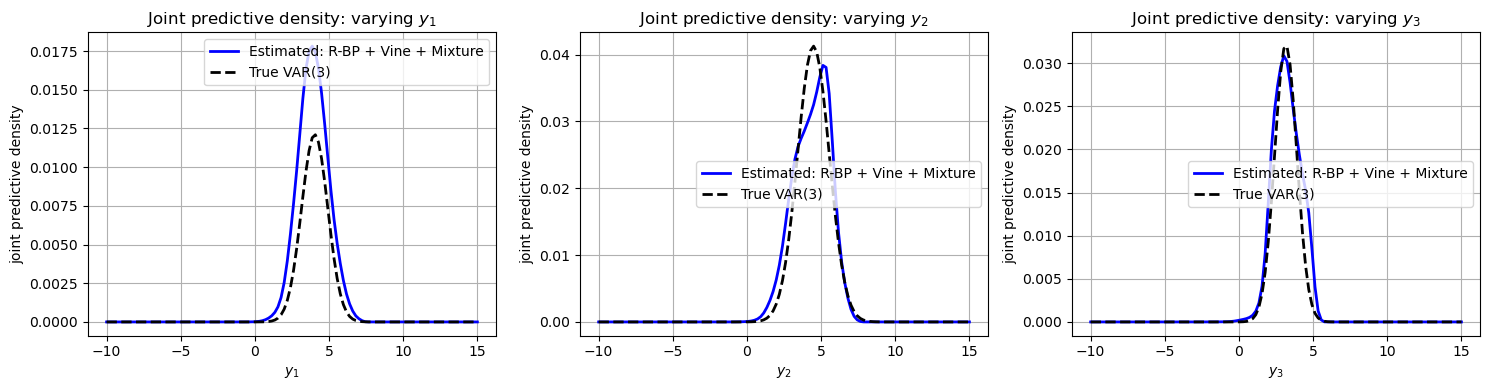

In [172]:
# ============================================================
# Estimated joint density와 true VAR(3) density 비교
# ============================================================



# ------------------------------------------------------------
# True VAR(3) conditional mean
# ------------------------------------------------------------

mean_true = A1 @ X_train[-1] + A2 @ X_train[-2] + A3 @ X_train[-3]

print("True conditional mean:")
print(mean_true)


# ------------------------------------------------------------
# 변수별 joint density 단면 그림
# ------------------------------------------------------------

fig, axes = plt.subplots(1,3,figsize=(15, 4))


for j in range(3):

    # j번째 변수를 변화시킬 grid
    y_grid_j = np.linspace( x_grids[j].min(), x_grids[j].max(), 120)

    # 나머지 두 변수는 실제 관측값 y로 고정
    candidate_points = np.tile(y, (len(y_grid_j), 1))

    # j번째 변수만 grid 값으로 변화
    candidate_points[:, j] = y_grid_j

    # --------------------------------------------------------
    # Estimated joint predictive density
    # --------------------------------------------------------

    estimated_curve = np.array([estimated_joint_density_at( candidate )for candidate in candidate_points])

    # --------------------------------------------------------
    # True VAR(3) joint conditional density
    # --------------------------------------------------------

    true_curve = multivariate_normal.pdf(candidate_points, mean=mean_true, cov=Sigma)

    # Estimated density
    axes[j].plot(y_grid_j, estimated_curve, color="blue", linewidth=2, label="Estimated: R-BP + Vine + Mixture")

    # True density
    axes[j].plot(y_grid_j, true_curve,
                 color="black", linestyle="--", linewidth=2,
                 label="True VAR(3)")

    # 실제 다음 관측값
    axes[j].set_title(rf"Joint predictive density: varying $y_{{{j+1}}}$")
    axes[j].set_xlabel(rf"$y_{{{j+1}}}$")

    axes[j].set_ylabel("joint predictive density")

    axes[j].grid(True)
    axes[j].legend()


plt.tight_layout()
plt.show()

In [199]:
# ============================================================
# MH proposal distribution
# ============================================================
proposal = mvn_def()
random_proposal = sample_mvn()

# 시작 위치
initial_position = np.asarray(X_train[-1], dtype=float)

In [203]:
mh_samples = metropolis_hastings(target=estimated_joint_density_at,
                                 proposal=proposal,
                                 random_proposal=random_proposal,
                                 initial_position=initial_position,
                                 chain_length=3000,
                                 burn_in=500)

print("MH samples shape:")
print(mh_samples.shape)

MH samples shape:
(2500, 3)


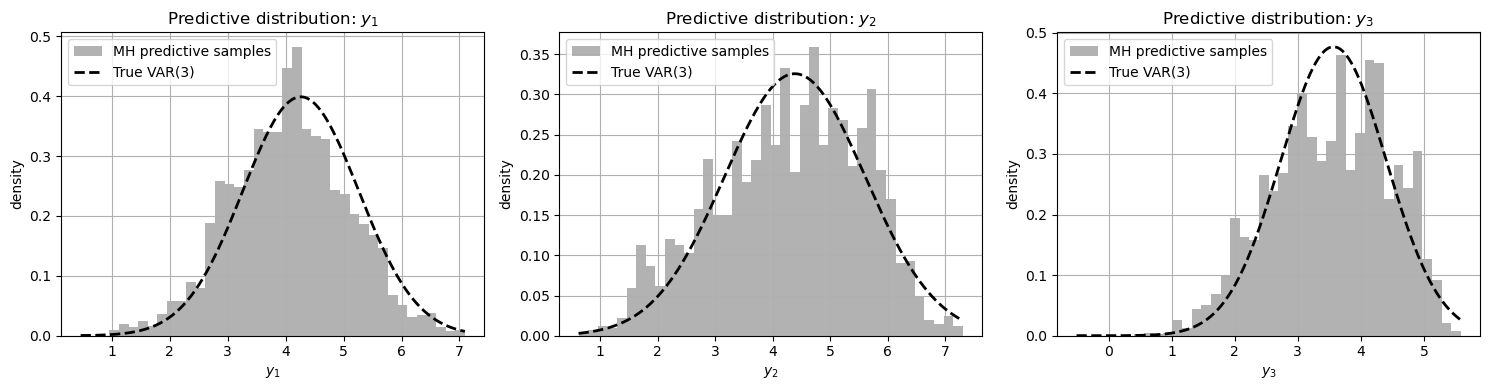

In [202]:
# ============================================================
#  MH sample과 true VAR(3) marginal 비교
# ============================================================

mean_true = (A1 @ X_train[-1]+ A2 @ X_train[-2]+ A3 @ X_train[-3])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for j in range(3):

    x_plot = np.linspace(mh_samples[:, j].min(),mh_samples[:, j].max(),300)

    true_marginal = norm.pdf( x_plot, loc=mean_true[j], scale=np.sqrt(Sigma[j, j]))

    # MH predictive sample
    axes[j].hist(mh_samples[:, j], 
                 bins=40, density=True, alpha=0.6,
                 color="grey",
                 label="MH predictive samples")

    # True VAR(3) conditional marginal
    axes[j].plot(x_plot, true_marginal,
                 color="black",linestyle="--",linewidth=2,
                label="True VAR(3)")

    axes[j].set_title(rf"Predictive distribution: $y_{{{j+1}}}$")

    axes[j].set_xlabel(rf"$y_{{{j+1}}}$")

    axes[j].set_ylabel("density")
    axes[j].grid(True)
    axes[j].legend()

plt.tight_layout()
plt.show()